Dataset: http://nlp.uit.edu.vn/datasets/

Classify 7 states of emotions in terms of enjoyment, disgust, sadness, anger, surprise, fear and others from text using PhoBert, a state of the art pre-trained BERT for the Vietnamese language

From UIT with ♥

### About data:

Emotion recognition is a higher approach or special case of sentiment analysis. In this task, the result is not produced in terms of either polarity: positive or negative or in the form of rating (from 1 to 5) but of a more detailed level of sentiment analysis in which the result are depicted in more expressions like sadness, enjoyment, anger, disgust, fear and surprise. Emotion recognition plays a critical role in measuring brand value of a product by recognizing specific emotions of customers’ comments. In this study, we have achieved two targets. First and foremost, we built a standard Vietnamese Social Media Emotion Corpus (UIT-VSMEC) with about 6,927 human-annotated sentences with six emotion labels, contributing to emotion recognition research in Vietnamese which is a low-resource language in Natural Language Processing (NLP). Secondly, we assessed and measured machine learning and deep neural network models on our UIT-VSMEC. As a result, Convolutional Neural Network (CNN) model achieved the highest performance with 57.61% of F1-score.

### Set Up

In [1]:
# For read excel format form pandas
!pip install openpyxl -q
# For Vietnamese word_segment
!pip install underthesea -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 56.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.6/978.6 kB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 93.9 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.7.2 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.7.2 which is incompatible.


In [2]:
import os
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from underthesea import word_tokenize
from gensim.utils import simple_preprocess
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix

import torch.nn as nn
from torch.optim import AdamW
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import get_linear_schedule_with_warmup, AutoTokenizer, AutoModel, logging

import warnings
warnings.filterwarnings("ignore")

logging.set_verbosity_error()

In [4]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
EPOCHS = 6
N_SPLITS = 10
print(f"Using : {device} ....")

Using : cuda:0 ....


### Load Data

In [5]:
def get_data_df(path):
    df = pd.read_excel(path, sheet_name=None)['Sheet1']
    df.columns = ['index', 'Emotion', 'Sentence']
    # unused column
    df.drop(columns=['index'], inplace=True)
    return df

train_df = get_data_df('../input/vsmec-dataset/UIT-VSMEC/train_nor_811.xlsx')
valid_df = get_data_df('../input/vsmec-dataset/UIT-VSMEC/valid_nor_811.xlsx')
test_df = get_data_df('../input/vsmec-dataset/UIT-VSMEC/test_nor_811.xlsx')

train_df#.head(10)

,Emotion,Sentence
0,Other,cho mình xin bài nhạc tên là gì với ạ
1,Disgust,cho đáng đời con quỷ . về nhà lôi con nhà mày ...
2,Disgust,lo học đi . yêu đương lol gì hay lại thích học...
3,Enjoyment,uớc gì sau này về già vẫn có thể như cụ này :))
4,Enjoyment,mỗi lần có video của con là cứ coi đi coi lại ...
...,...,...
5543,Disgust,đường của nhà cụ hay sao mà cụ cấm người ta đỗ...
5544,Other,nhìn mặt héo queo luôn
5545,Other,tao đi xe máy mỗi lần muốn để xe đi đâu là phi...
5546,Enjoyment,thích thân hình boss rồi nhan 😌


In [6]:
train_df = pd.concat([train_df, valid_df], ignore_index=True)
skf = StratifiedKFold(n_splits=N_SPLITS)

for fold_id, (_, ids_row_) in enumerate(skf.split(X=train_df, y=train_df.Emotion)):
    train_df.loc[ids_row_, "kfold"] = fold_id

In [7]:
train_df.sample(10)

,Emotion,Sentence,kfold
3706,Enjoyment,dễ thương ghê ! làm mình nhớ các cậu bạn cùng ...,5.0
3913,Enjoyment,đáng yêuc vãi anh ơi,6.0
234,Surprise,bất ngờ chưa =))),0.0
658,Surprise,cha con y chang nhau 😂 1 khuôn đúc ra,1.0
821,Enjoyment,lợi ích của việc giữ vững quan điểm 😄,1.0
2074,Anger,bó tay . lại khiển trách . rút kinh nghiệm,3.0
1773,Other,"per 2ce thì có thể làm được , ly mà làm như vầ...",2.0
592,Sadness,trước khi lấy vợ boss có một thân hình hoàn mĩ...,1.0
5674,Enjoyment,già còn thích phi công =)),9.0
2856,Disgust,dăm ba cái yêu đương vớ vẩn :)),4.0


In [8]:
train_df.info(), test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6234 entries, 0 to 6233
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Emotion   6234 non-null   object 
 1   Sentence  6234 non-null   object 
 2   kfold     6234 non-null   float64
dtypes: float64(1), object(2)
memory usage: 146.2+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 693 entries, 0 to 692
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Emotion   693 non-null    object
 1   Sentence  693 non-null    object
dtypes: object(2)
memory usage: 11.0+ KB


(None, None)

<Axes: xlabel='Emotion', ylabel='count'>

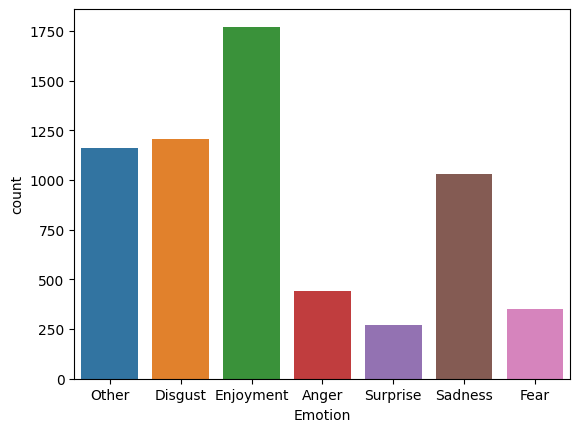

In [9]:
sns.countplot(x='Emotion', data=train_df)

### DataLoader

In [10]:
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base-v2", use_fast=False)

config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [11]:
class SentimentDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=120):
        self.df = df
        self.max_len = max_len
        self.tokenizer = tokenizer
    
    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        """
        To customize dataset, inherit from Dataset class and implement
        __len__ & __getitem__
        __getitem__ should return 
            data:
                input_ids
                attention_masks
                text
                targets
        """
        row = self.df.iloc[idx]
        text, label = self.get_input_data_and_label(row)

        # Encode_plus will:
        # (1) split text into token
        # (2) Add the '[CLS]' and '[SEP]' token to the start and end
        # (3) Truncate/Pad sentence to max length
        # (4) Map token to their IDS
        # (5) Create attention mask
        # (6) Return a dictionary of outputs
        encoding = self.tokenizer.encode_plus(
            text,
            truncation=True,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            return_attention_mask=True,
            return_token_type_ids=False,
            return_tensors='pt',
        )
        
        return {
            'text': text,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_masks': encoding['attention_mask'].flatten(),
            'targets': torch.tensor(label, dtype=torch.long),
        }


    def _labelencoder(self,text):
        if text=='Enjoyment':
            return 0
        elif text=='Disgust':
            return 1
        elif text=='Sadness':
            return 2
        elif text=='Anger':
            return 3
        elif text=='Surprise':
            return 4
        elif text=='Fear':
            return 5
        else:
            return 6 # other

    def get_input_data_and_label(self, row):
        # Preprocessing: {remove icon, special character, lower}
        text = row['Sentence']
        text = ' '.join(simple_preprocess(text))
        text = word_tokenize(text, format = "text")
        label = self._labelencoder(row['Emotion'])

        return text, label




Text(0.5, 9.444444444444438, 'Token Count')

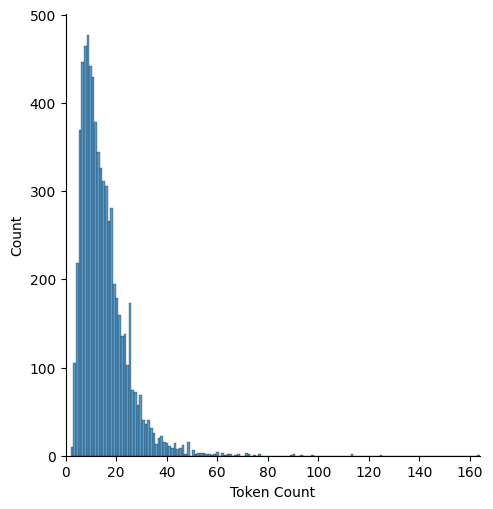

In [12]:
# Distribution of length of Sentence
all_data = train_df.Sentence.tolist() + test_df.Sentence.tolist()
all_data = [' '.join(simple_preprocess(text)) for text in all_data]

encoded_text = [tokenizer.encode(text, add_special_tokens=True) for text in all_data]
token_lens = [len(text) for text in encoded_text]

sns.displot(token_lens)
plt.xlim([0,max(token_lens)])
plt.xlabel('Token Count')



### Model

In [13]:
class PhoBERTClassifierforSentiment(nn.Module):
    def __init__(self, n_classes):
        super(PhoBERTClassifierforSentiment, self).__init__()
        self.bert = AutoModel.from_pretrained("vinai/phobert-base-v2")
        self.dropout = nn.Dropout(p=0.3)
        self.fc = nn.Linear(self.bert.config.hidden_size, n_classes)
        nn.init.normal_(self.fc.weight, std=0.02)
        nn.init.normal_(self.fc.bias, 0)

    def forward(self, input_ids, attention_mask):
        last_hidden_state, output = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=False # Dropout will errors if without this
        )

        x = self.dropout(output)
        x = self.fc(x)
        return x

### Train & Eval Function

In [14]:
def train(model, criterion, optimizer, train_loader, weights = None):
    model.train()
    losses = []
    correct = 0

    for data in train_loader:
        input_ids = data['input_ids'].to(device)
        attention_mask = data['attention_masks'].to(device)
        targets = data['targets'].to(device)

        optimizer.zero_grad()
        outputs_logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        loss = criterion(outputs_logits, targets)

        if weights is not None :
            weight_per_sample = weights[targets]
            loss = (weight_per_sample * loss).mean()
        else:
            loss= loss.mean()
            
        _, pred = torch.max(outputs_logits, dim=1)

        correct += torch.sum(pred == targets)
        losses.append(loss.item())
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        lr_scheduler.step()

    print(f'Train Accuracy: {correct.double()/len(train_loader.dataset)} Loss: {np.mean(losses)}')




def eval(criterion, valid_loader):
    model.eval()
    losses = []
    correct = 0

    with torch.no_grad():
        # data_loader = test_loader if test_data else valid_loader
        for data in valid_loader:
            input_ids = data['input_ids'].to(device)
            attention_mask = data['attention_masks'].to(device)
            targets = data['targets'].to(device)

            outputs_logits = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            _, pred = torch.max(outputs_logits, dim=1)

            loss = criterion(outputs_logits, targets).mean()
            correct += torch.sum(pred == targets)
            losses.append(loss.item())
    acc = correct.double() / len(valid_loader.dataset)
    print(f'Valid Accuracy: {acc:.4f} Loss: {np.mean(losses):.4f}')
    return acc


In [15]:
class LDAMLoss(nn.Module):
    def __init__(self, cls_num_list, max_m=0.5, s=30, reduction='none'):
        super(LDAMLoss, self).__init__()
        
        m_list = 1.0 / np.power(cls_num_list, 0.25) 
        m_list = m_list * (max_m / np.max(m_list))   
        
        m_list = torch.FloatTensor(m_list).to(device)
        
        self.m_list = m_list 
        self.s = s # scaling factor
        self.reduction = reduction # None for DRW

    def forward(self, x, target):
        # x:      (batch_size, num_classes)
        # target: (batch_size)
        
        index = torch.zeros_like(x, dtype=torch.bool)
        index.scatter_(1, target.data.view(-1, 1), 1) # (scatter_follow_dim, coor_idx, scatted_values)
        
        # get margins of classes in target -> Shape: (shape of target, 1)
        margins = self.m_list[target].unsqueeze(1)
        
        logits_y = x.gather(1, target.unsqueeze(1)) # (follow_dim , idx_of_follow_dim)
        
        logits_y_with_margin = logits_y - margins
            
        x_with_margin = torch.where(index, logits_y_with_margin, x)
        

        return F.cross_entropy(self.s * x_with_margin, target, reduction=self.reduction)

In [16]:
label_counts = train_df['Emotion'].value_counts().sort_index()
print(f"Number sample per classes: \n {label_counts}")
cls_num_list = [
    label_counts.get('Enjoyment', 0),
    label_counts.get('Disgust', 0),
    label_counts.get('Sadness', 0),
    label_counts.get('Anger', 0),
    label_counts.get('Surprise', 0),
    label_counts.get('Fear', 0),
    label_counts.get('Other', 0)
]

cls_num_array = np.array(cls_num_list)

print(f"\nClass number list (index 0-6): {cls_num_list}")

DRW_EPOCH_THRESHOLD = 3 
print(f"\nDeferred Re-Weighting will begin from epoch: {DRW_EPOCH_THRESHOLD}")

per_clss_weights = np.where(cls_num_array > 0, 1.0/cls_num_array, 0)
per_clss_weights = per_clss_weights / sum(per_clss_weights)
per_clss_weights = torch.FloatTensor(per_clss_weights).to(device)
print(f"\nNormalized Weight of DRW: {per_clss_weights}")

Number sample per classes: 
 Emotion
Anger         440
Disgust      1206
Enjoyment    1772
Fear          349
Other        1162
Sadness      1033
Surprise      272
Name: count, dtype: int64

Class number list (index 0-6): [1772, 1206, 1033, 440, 272, 349, 1162]

Deferred Re-Weighting will begin from epoch: 3

Normalized Weight of DRW: tensor([0.0469, 0.0689, 0.0804, 0.1888, 0.3054, 0.2380, 0.0715],
       device='cuda:0')


### Training with K-Fold

In [17]:
def prepare_loaders(df, fold):
    df_train = df[df.kfold != fold].reset_index(drop=True)
    df_valid = df[df.kfold == fold].reset_index(drop=True)
    
    train_dataset = SentimentDataset(df_train, tokenizer, max_len=60)
    valid_dataset = SentimentDataset(df_valid, tokenizer, max_len=60)
    
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=4)
    valid_loader = DataLoader(valid_dataset, batch_size=16, shuffle=True, num_workers=4)
    
    return train_loader, valid_loader

In [18]:
print(f"NUMBER EPOCH FOR PER FOLD: {EPOCHS}")

for fold in range(skf.n_splits):
    print('-'*30 + f' Fold: {fold+1} ' + '-'*30)
    train_loader, valid_loader = prepare_loaders(train_df, fold=fold)
    
    model = PhoBERTClassifierforSentiment(n_classes=7).to(device)
    
    loss_function = LDAMLoss(cls_num_list=cls_num_array)
    # Recommendation by BERT: lr: 5e-5, 2e-5, 3e-5
    # Batchsize: 16, 32
    optimizer = AdamW(model.parameters(), lr=3e-5)
    
    lr_scheduler = get_linear_schedule_with_warmup(
                optimizer, 
                num_warmup_steps=0, 
                num_training_steps=len(train_loader)*EPOCHS
            )
    
    best_acc = 0
    for epoch in range(EPOCHS):
        print(f'Epoch {epoch+1}/{EPOCHS}')
        print('-'*60)

        current_weights = None 
        if epoch >= DRW_EPOCH_THRESHOLD:
            print(f"--- Epoch {epoch+1} >= {DRW_EPOCH_THRESHOLD}. Apply Deferred Re-Weighting (DRW) ---")
            current_weights = per_clss_weights
        
        train(model, loss_function, optimizer, train_loader, weights = current_weights)
        val_acc = eval(criterion=loss_function, valid_loader=valid_loader)

        if val_acc > best_acc:
            torch.save(model.state_dict(), f'phobert_fold{fold+1}.pth')
            best_acc = val_acc

NUMBER EPOCH FOR PER FOLD: 6
------------------------------ Fold: 1 ------------------------------


2025-11-10 05:31:53.570634: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762752713.971774      48 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762752714.124650      48 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]

Epoch 1/6
------------------------------------------------------------
Train Accuracy: 0.360427807486631 Loss: 13.92729921286602
Valid Accuracy: 0.5192 Loss: 10.7416
Epoch 2/6
------------------------------------------------------------
Train Accuracy: 0.6065953654188948 Loss: 9.425715045032339
Valid Accuracy: 0.6154 Loss: 9.0956
Epoch 3/6
------------------------------------------------------------
Train Accuracy: 0.7126559714795009 Loss: 7.1419703943437325
Valid Accuracy: 0.6346 Loss: 9.1730
Epoch 4/6
------------------------------------------------------------
--- Epoch 4 >= 3. Apply Deferred Re-Weighting (DRW) ---
Train Accuracy: 0.7729055258467022 Loss: 0.6217709209483403
Valid Accuracy: 0.6282 Loss: 9.7627
Epoch 5/6
------------------------------------------------------------
--- Epoch 5 >= 3. Apply Deferred Re-Weighting (DRW) ---
Train Accuracy: 0.8327985739750445 Loss: 0.44942699433795236
Valid Accuracy: 0.5929 Loss: 10.6351
Epoch 6/6
-------------------------------------------

In [19]:
def test_kfold(data_loader):
    models = []
    for fold in range(skf.n_splits):
        model = SentimentClassifier(n_classes=7)
        model.to(device)
        model.load_state_dict(torch.load(f'phobert_fold{fold+1}.pth'))
        model.eval()
        models.append(model)

    texts = []
    predicts = []
    predict_probs = []
    real_values = []

    for data in data_loader:
        text = data['text']
        input_ids = data['input_ids'].to(device)
        attention_mask = data['attention_masks'].to(device)
        targets = data['targets'].to(device)

        total_outs = []
        for model in models:
            with torch.no_grad():
                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask
                )
                total_outs.append(outputs)
        
        total_outs = torch.stack(total_outs)
        _, pred = torch.max(total_outs.mean(0), dim=1)
        texts.extend(text)
        predicts.extend(pred)
        predict_probs.extend(total_outs.mean(0))
        real_values.extend(targets)
    
    predicts = torch.stack(predicts).cpu()
    predict_probs = torch.stack(predict_probs).cpu()
    real_values = torch.stack(real_values).cpu()
    print(classification_report(real_values, predicts))
    return real_values, predicts

In [20]:
def evaluate_ensemble(test_loader):
    
    print(f"Loading {skf.n_splits} model from folds...")
    ensemble_models = []
    for i in range(skf.n_splits):
        fold_path = f'phobert_fold{i+1}.pth'
        
        fold_model = PhoBERTClassifierforSentiment(n_classes=7)
        fold_model.to(device)
        
        fold_model.load_state_dict(torch.load(fold_path, map_location=device))
        fold_model.eval()
        
        ensemble_models.append(fold_model)
    print("Load All Model: OK !!!")

    all_targets = []
    all_predictions = []
    all_avg_logits = []
    all_texts = []

    print("Running predict (ensemble) on test_df...")
    for batch in test_loader:
        
        batch_texts = batch['text']
        batch_ids = batch['input_ids'].to(device)
        batch_mask = batch['attention_masks'].to(device)
        batch_targets = batch['targets'].to(device)

        
        batch_fold_outputs = []

        with torch.no_grad():
            for model in ensemble_models:
                logits = model(input_ids=batch_ids, attention_mask=batch_mask)
                batch_fold_outputs.append(logits)
        
    
        stacked_logits = torch.stack(batch_fold_outputs) # (K, batch_size, n_classes)
        
        avg_logits = stacked_logits.mean(dim=0) # (batch_size, n_classes)
        
        _, predicted_labels = torch.max(avg_logits, dim=1)

        
        all_texts.extend(batch_texts)
        all_predictions.extend(predicted_labels)
        all_avg_logits.extend(avg_logits)
        all_targets.extend(batch_targets)

    print("Creating report...")
    
    
    final_predictions = torch.stack(all_predictions).cpu()
    final_targets = torch.stack(all_targets).cpu()
    # final_logits = torch.stack(all_avg_logits).cpu() 

    
    print(classification_report(final_targets, final_predictions))

    return final_targets, final_predictions

In [21]:
test_dataset = SentimentDataset(test_df, tokenizer, max_len=60)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=True, num_workers=4)
real_values, predicts = evaluate_ensemble(test_loader)

Loading 10 model from folds...
Load All Model: OK !!!
Running predict (ensemble) on test_df...
Creating report...
              precision    recall  f1-score   support

           0       0.72      0.68      0.70       193
           1       0.69      0.63      0.66       132
           2       0.68      0.66      0.67       116
           3       0.51      0.60      0.55        40
           4       0.59      0.70      0.64        37
           5       0.60      0.72      0.65        46
           6       0.57      0.57      0.57       129

    accuracy                           0.65       693
   macro avg       0.62      0.65      0.63       693
weighted avg       0.65      0.65      0.65       693



### Heatmap between Predict and Ground Truth

<Axes: >

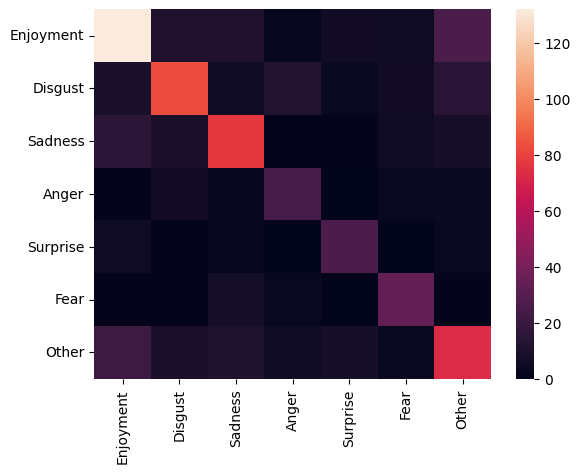

In [22]:
class_names = ['Enjoyment', 'Disgust', 'Sadness', 'Anger', 'Surprise', 'Fear', 'Other']
sns.heatmap(confusion_matrix(real_values, predicts), annot=False, xticklabels = class_names, yticklabels = class_names)

=> Label Fear is the most unrelated to others -> Highest F1-Score

### Visualize Wrong Predicted Label

In [24]:
def check_wrong(real_values, predicts):
    wrong_arr = []
    wrong_label = []
    for i in range(len(predicts)):
        if predicts[i] != real_values[i]:
            wrong_arr.append(i)
            wrong_label.append(predicts[i])
    return wrong_arr, wrong_label

wrong_arr, wrong_label = check_wrong(real_values, predicts)
print(f'Number of sample: {len(predicts)}')
print(f'Number of Fail sample: {len(wrong_arr)}')
for i in range(15):
    print('-'*60)
    
    print(test_df.iloc[wrong_arr[i]].Sentence)
    print(f'Predicted: ({class_names[wrong_label[i]]}) --vs-- Real label: ({class_names[real_values[wrong_arr[i]]]})')

Number of sample: 693
Number of Fail sample: 245
------------------------------------------------------------
cho nghỉ viêc mói đúng sao goi là kỷ luật
Predicted: (Surprise) --vs-- Real label: (Other)
------------------------------------------------------------
nhà thì không xa lắm nhưng chưa bao giờ đi vì sợ bị đè bẹp luôn người =)))))
Predicted: (Disgust) --vs-- Real label: (Surprise)
------------------------------------------------------------
per trình mày vẫn còn thấp chán =))
Predicted: (Other) --vs-- Real label: (Enjoyment)
------------------------------------------------------------
mấy ai được như vậy ??
Predicted: (Fear) --vs-- Real label: (Disgust)
------------------------------------------------------------
góp vui cho chủ thớt 😂😂
Predicted: (Anger) --vs-- Real label: (Fear)
------------------------------------------------------------
sống 17 năm chưa crush ai bao giờ
Predicted: (Enjoyment) --vs-- Real label: (Other)
---------------------------------------------------------

### Inference

In [25]:
def infer(text, model, tokenizer, max_len=60):
    print(f'Text: {text}')
    text = ' '.join(simple_preprocess(text))
    # text = ViTokenizer.tokenize(text)
    text = word_tokenize(text, format = "text")
    
    encoded_review = tokenizer.encode_plus(
        text,
        max_length=max_len,
        truncation=True,
        add_special_tokens=True,
        padding='max_length',
        return_attention_mask=True,
        return_token_type_ids=False,
        return_tensors='pt',
    )

    input_ids = encoded_review['input_ids'].to(device)
    attention_mask = encoded_review['attention_mask'].to(device)
    
    with torch.no_grad():
        output = model(input_ids, attention_mask)
        
    _, y_pred = torch.max(output, dim=1)

    print(f'Sentiment: {class_names[y_pred]}')

In [26]:
fold_k_model = 6 # 8
infer_model = PhoBERTClassifierforSentiment(n_classes=7)
infer_model.load_state_dict(torch.load(f'phobert_fold{fold_k_model}.pth'))
infer_model.to(device)
infer_model.eval()
print('-'*30 +'Loaded Model for Inference !!!!!!' + '-'*30)

infer('Chúc một ngày tốt lành nha!',
      infer_model, 
      tokenizer
     )

print('-'*30)
infer('Trời ơi coi cái con chó kia nó làm gì kìa, bực cả mình.',
      infer_model,
      tokenizer
     )

------------------------------Loaded Model for Inference !!!!!!------------------------------
Text: Chúc một ngày tốt lành nha!
Sentiment: Enjoyment
------------------------------
Text: Trời ơi coi cái con chó kia nó làm gì kìa, bực cả mình.
Sentiment: Anger


### References:

* https://github.com/VinAIResearch/PhoBERT

* http://nlp.uit.edu.vn/datasets/